# **Подготовка данных**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Скачивание и распаковка датасета
!wget https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip -q
!unzip -q bus.zip -d bus_dataset

# Путь к папкам
base_dir = 'bus_dataset'
categories = ['Входящий', 'Выходящий']
img_size = 64


# **Загрузка и обработка изображений**

In [2]:
def load_data():
    data = []
    labels = []

    for category in categories:
        path = os.path.join(base_dir, category)
        class_num = categories.index(category)

        for img_name in os.listdir(path):
            try:
                img = Image.open(os.path.join(path, img_name)).convert('RGB').resize((img_size, img_size))
                data.append(np.array(img))
                labels.append(class_num)
            except Exception:
                pass

    return np.array(data) / 255.0, np.array(labels)

# Загружаем данные
X, y = load_data()

# Разделяем на обучающую и проверочную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Размер обучающей выборки:   {X_train.shape}')
print(f'Размер проверочной выборки: {X_val.shape}')


Размер обучающей выборки:   (7264, 64, 64, 3)
Размер проверочной выборки: (1817, 64, 64, 3)


# **Создание модели**

Используем свёрточную нейронную сеть (CNN) — она работает с изображениями лучше, чем полносвязная, потому что учитывает пространственные связи между пикселями.


In [3]:
model = Sequential([
    # Первый свёрточный блок
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(img_size, img_size, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Второй свёрточный блок
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Третий свёрточный блок
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Классификатор
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')   # 0 - входящий, 1 - выходящий
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,977 (4.36 MB)

 Trainable params: 1,142,529 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

# **Обучение и результат**

In [4]:
# EarlyStopping останавливает обучение, если точность перестала расти
early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Финальная точность
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f'\nТочность на проверочной выборке: {val_acc*100:.2f}%')
print(f'Порог 85% {"пройден ✅" if val_acc >= 0.85 else "НЕ пройден ❌"}')


Epoch 1/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8181 - loss: 0.5251 - val_accuracy: 0.7744 - val_loss: 0.4767
Epoch 2/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8979 - loss: 0.2368 - val_accuracy: 0.9081 - val_loss: 0.2153
Epoch 3/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9258 - loss: 0.1761 - val_accuracy: 0.9444 - val_loss: 0.1373
Epoch 4/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9470 - loss: 0.1220 - val_accuracy: 0.9697 - val_loss: 0.0738
Epoch 5/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9540 - loss: 0.1038 - val_accuracy: 0.9450 - val_loss: 0.1374
Epoch 6/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9620 - loss: 0.0920 - val_accuracy: 0.9664 - val_loss: 0.0955
Epoch 7/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9659 - loss: 0.0935 - val_accuracy: 0.9598 - val_loss: 0.1042
Epoch 8/30
227/227 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9810 - loss: 0.0563 - val_accuracy: 

# **Графики обучения**

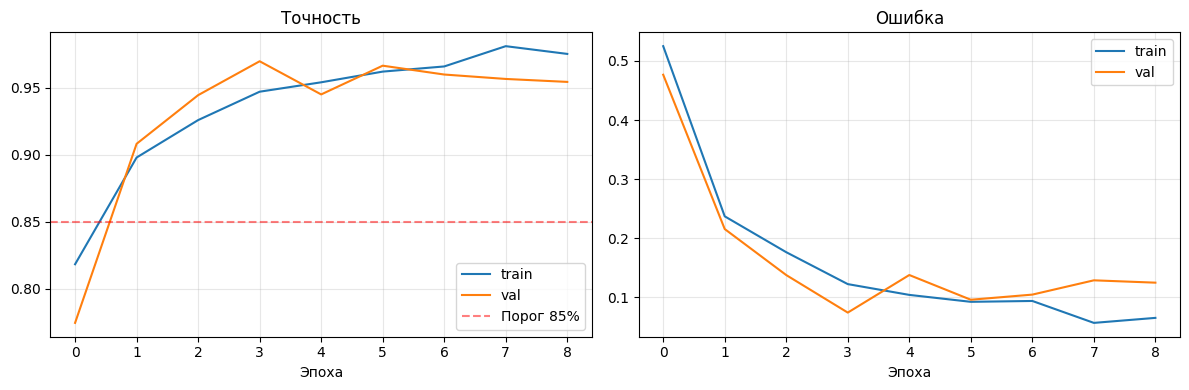

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].axhline(0.85, color='red', linestyle='--', alpha=0.5, label='Порог 85%')
axes[0].set_title('Точность')
axes[0].set_xlabel('Эпоха')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Ошибка')
axes[1].set_xlabel('Эпоха')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
